# Linear Regression wirth Python
Galton's phenomenon, often linked to linear regression, observes that "a son's height tends to move closer to the average height of the population rather than exactly matching the father's height." This concept laid the foundation for the statistical method of regression analysis, where the relationship between variables (e.g., a father's height and a son's height) is studied to predict outcomes while accounting for tendencies toward a central value (the mean).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%matplotlib inline

In [3]:
df=pd.read_csv('USA_Housing.csv')

In [4]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [9]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

# Exploratory Data Analysis
Let's dive into the data!

We'll focus solely on the numerical data from the CSV file.
First, we examine the distribution of house prices, as our goal is to predict them. Then, we'll use Seaborn to create a joint plot to visualize the relationship between the "Average Area Income" and "Price" columns.

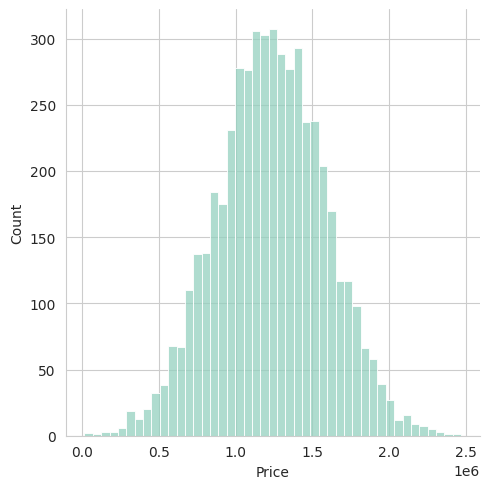

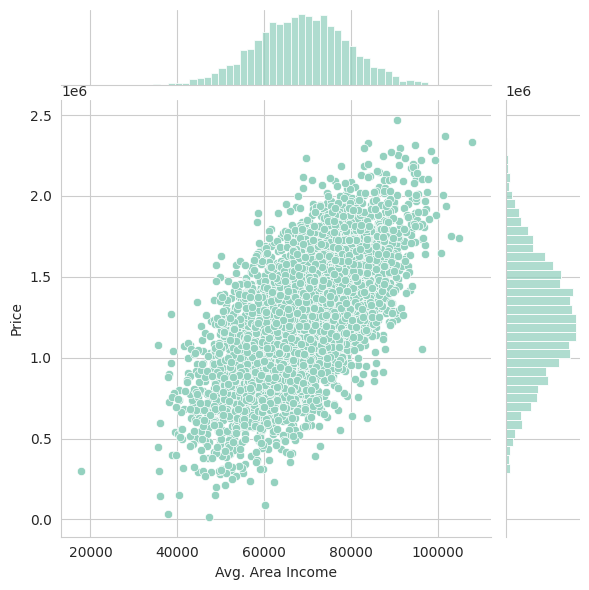

In [11]:
# sns.pairplot(customers)
sns.displot(df['Price'])
sns.set_palette("GnBu_d")
sns.set_style('whitegrid')
sns.jointplot(x='Avg. Area Income',y='Price',data=df)

In [23]:
df_numeric = df.select_dtypes(include='number')
correlation_matrix = df_numeric.corr()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
Avg. Area Income,1.000000,-0.002007,-0.011032,0.019788,-0.016234,0.639734
Avg. Area House Age,-0.002007,1.000000,-0.009428,0.006149,-0.018743,0.452543
Avg. Area Number of Rooms,-0.011032,-0.009428,1.000000,0.462695,0.002040,0.335664
Avg. Area Number of Bedrooms,0.019788,0.006149,0.462695,1.000000,-0.022168,0.171071
Area Population,-0.016234,-0.018743,0.002040,-0.022168,1.000000,0.408556
Price,0.639734,0.452543,0.335664,0.171071,0.408556,1.000000


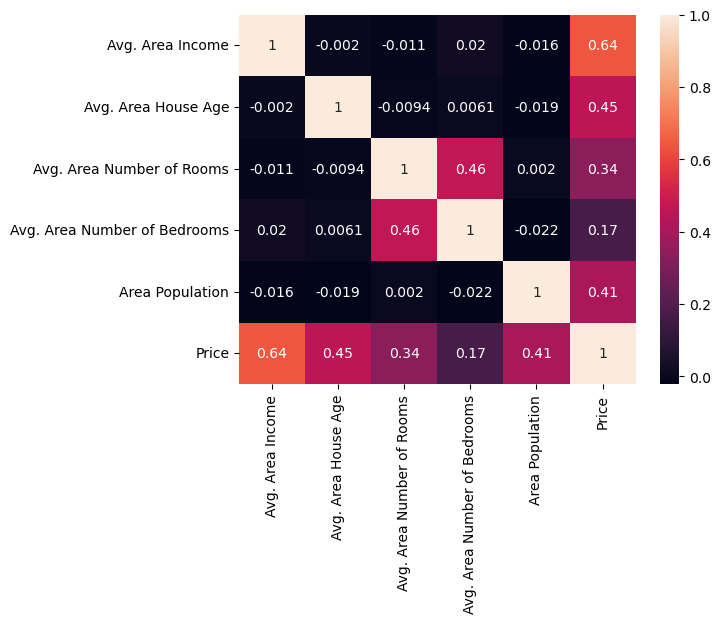

In [37]:
sns.heatmap(correlation_matrix,annot=True)
plt.show()

Next, we use `jointplot` to create a 2D hexbin plot to compare **Price** and **Average Area Income**.



In [ ]:
sns.jointplot(x='Avg. Area Income',y='price',kind='hex',data=df)

Let's examine these relationships across the entire dataset. Use [`pairplot`](https://stanford.edu/~mwaskom/software/seaborn/tutorial/axis_grids.html#plotting-pairwise-relationships-with-pairgrid-and-pairplot) to recreate the plot shown below. (No need to match the colors exactly.)

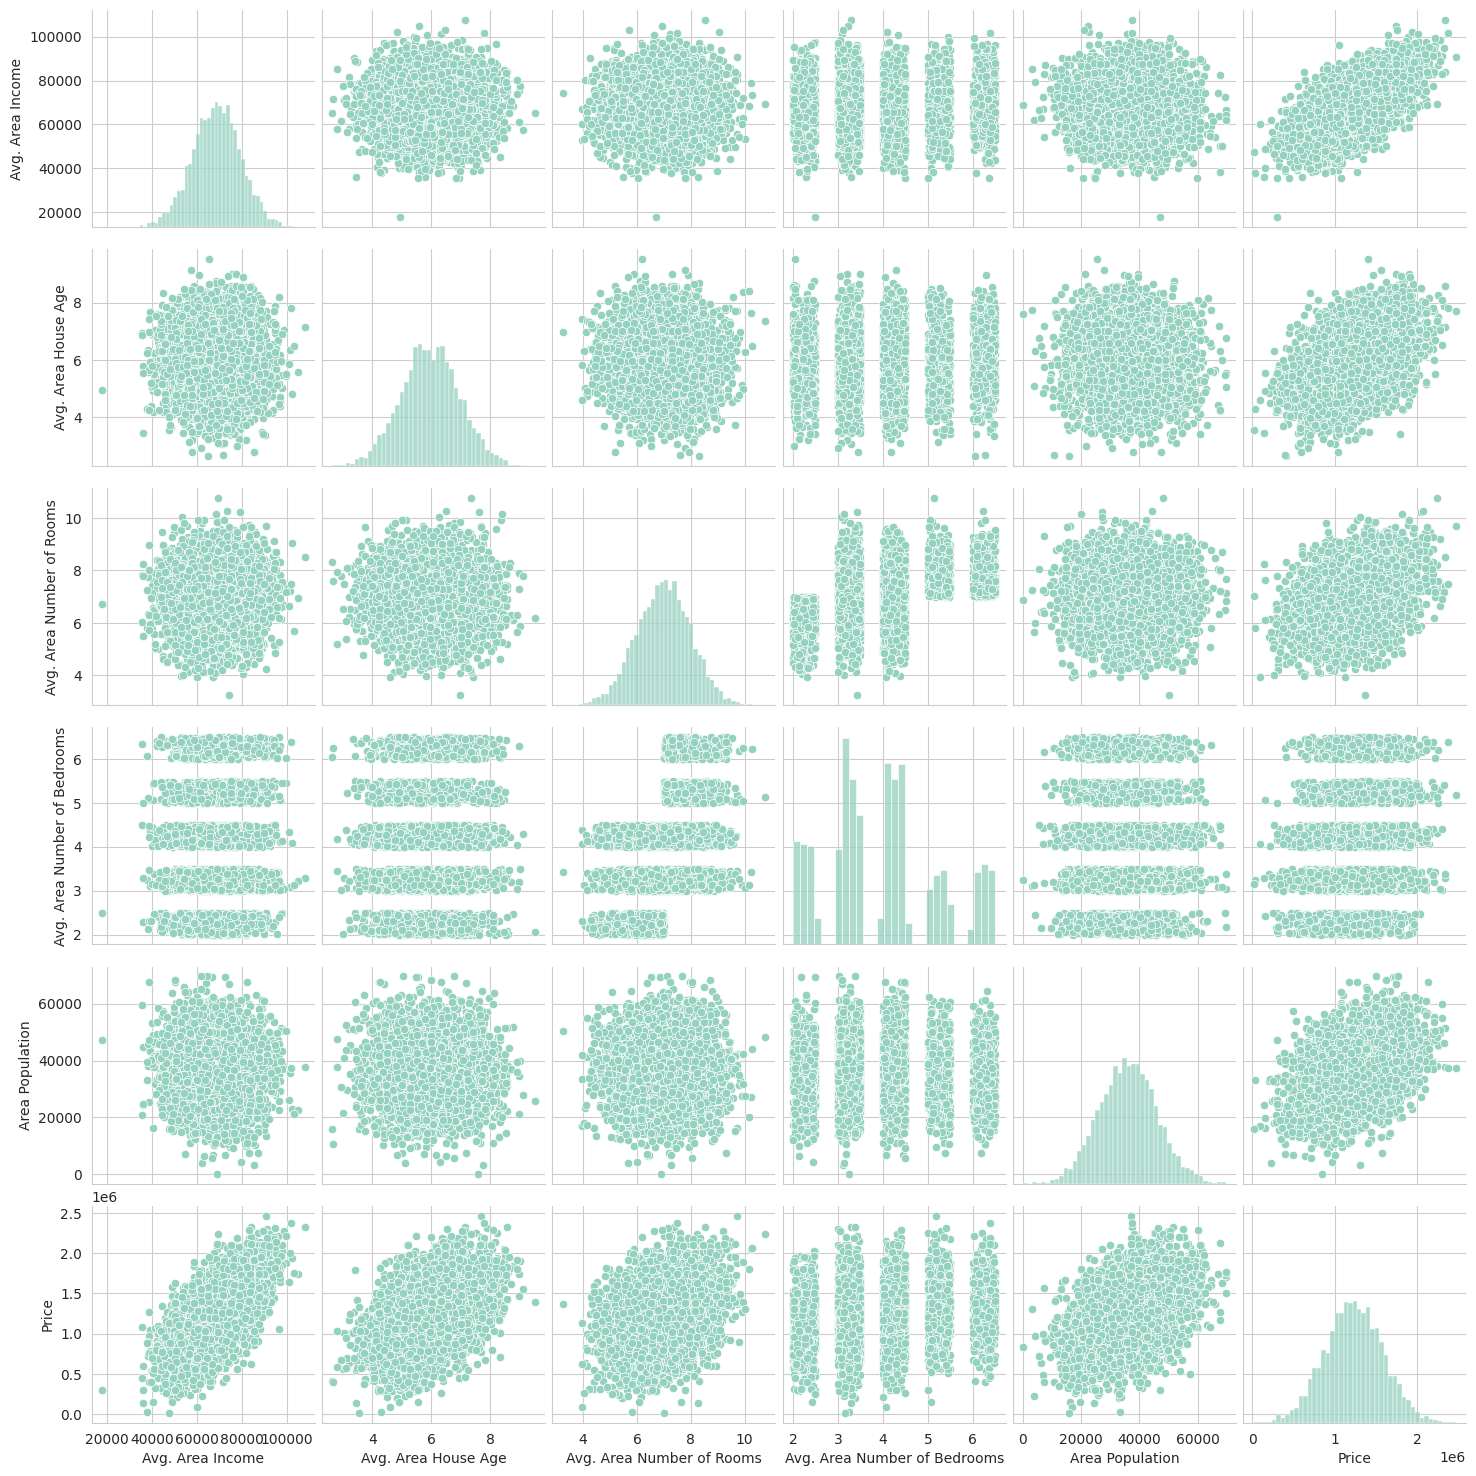

In [12]:
sns.pairplot(df)

Create a linear model plot using Seaborn's `lmplot` to visualize the relationship between **Price** and **Average Area Income**.

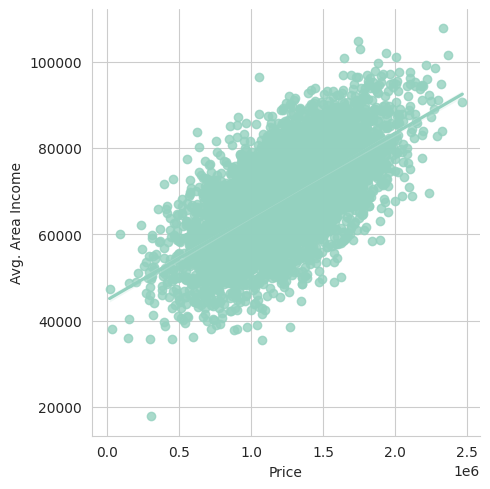

In [13]:
sns.lmplot(data=df,x='Price',y='Avg. Area Income')

## Training and Testing Data


In [21]:
from sklearn.model_selection import train_test_split

In [45]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='object')

In [79]:
df = df.drop('Address', axis=1)

In [81]:
df.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price'],
      dtype='object')

In [11]:
X=df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population']]

In [13]:
X

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,79545.458574,5.682861,7.009188,4.09,23086.800503
1,79248.642455,6.002900,6.730821,3.09,40173.072174
2,61287.067179,5.865890,8.512727,5.13,36882.159400
3,63345.240046,7.188236,5.586729,3.26,34310.242831
4,59982.197226,5.040555,7.839388,4.23,26354.109472
...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035
4996,78491.275435,6.999135,6.576763,4.02,25616.115489
4997,63390.686886,7.250591,4.805081,2.13,33266.145490
4998,68001.331235,5.534388,7.130144,5.44,42625.620156


In [15]:
y=df[['Price']]

In [17]:
y

,Price
0,1.059034e+06
1,1.505891e+06
2,1.058988e+06
3,1.260617e+06
4,6.309435e+05
...,...
4995,1.060194e+06
4996,1.482618e+06
4997,1.030730e+06
4998,1.198657e+06


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

In [25]:
from sklearn.linear_model import LinearRegression

In [26]:
model=LinearRegression()

In [29]:
model.fit(X_train,y_train)

LinearRegression()

In [31]:
model.intercept_

array([-2640159.7968527])

In [33]:
# Coefficients are going to relate to each feature  
print('Coefficients: \n',model.coef_)

Coefficients: 
 [[2.15282755e+01 1.64883282e+05 1.22368678e+05 2.23380186e+03
  1.51504200e+01]]


In [35]:
# Coefs as mydata, columns as index 
t_df=pd.DataFrame(model.coef_.T,X.columns,columns=['Coeff.'])
t_df

,Coeff.
Avg. Area Income,21.528276
Avg. Area House Age,164883.282027
Avg. Area Number of Rooms,122368.678027
Avg. Area Number of Bedrooms,2233.801864
Area Population,15.150420


# Predicting Test Data

In [38]:
predict=model.predict(X_test)

In [40]:
predict

array([[1260960.70567627],
       [ 827588.75560329],
       [1742421.24254344],
       ...,
       [ 372191.40626917],
       [1365217.15140899],
       [1914519.5417888 ]])

## Evaluation

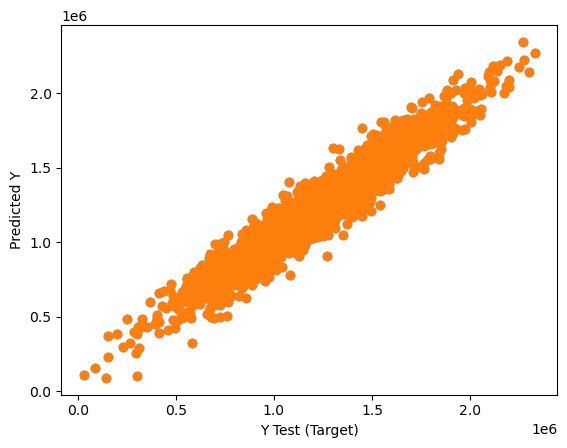

In [47]:
plt.scatter(y_test,predict)
plt.xlabel('Y Test (Target)')
plt.ylabel('Predicted Y')
plt.show()

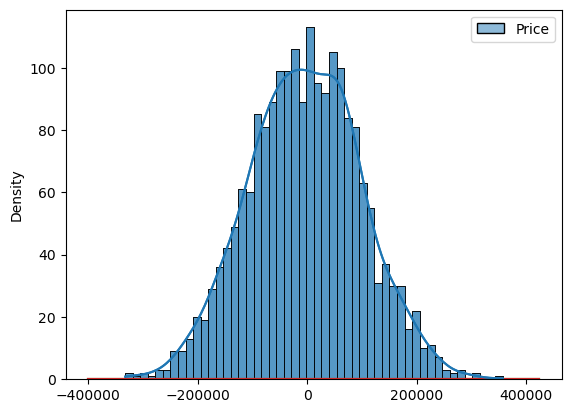

In [59]:
# create a histogram of our residuals (The difference between the actual value(y_test) and the predicted value)
# sns.distplot((y_test-predict),bins=50);
sns.histplot((y_test - predict), bins=50, kde=True)
plt.show
# it's normally distributed, which means your model is a correct choice for your data

In [61]:
from sklearn import metrics

print('MAE:', metrics.mean_absolute_error(y_test, predict))
print('MSE:', metrics.mean_squared_error(y_test, predict))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predict)))

MAE: 82288.22251914942
MSE: 10460958907.208977
RMSE: 102278.82922290897


## 2. Ecommerce Customers csv file

In [110]:
customers=pd.read_csv('Ecommerce Customers')

In [114]:
customers.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [120]:
customers.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [122]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


### EDA

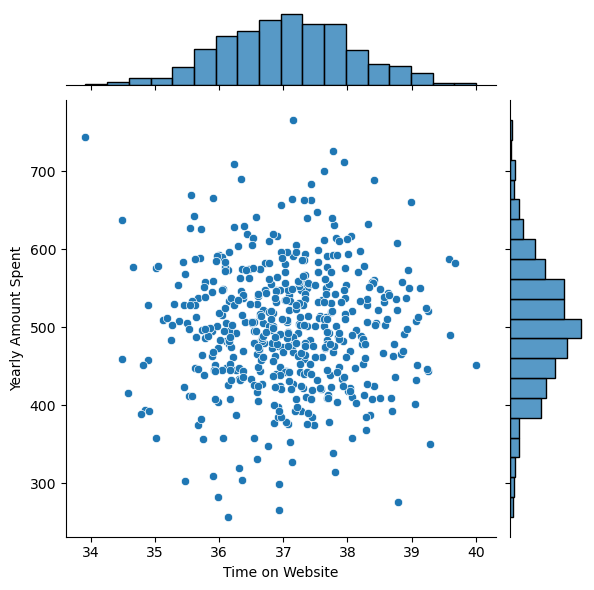

In [131]:
# sns.jointplot(x='Time on Website',y='Yearly Amount Spent',kind='hex',data=customers)
sns.jointplot(x='Time on Website',y='Yearly Amount Spent',data=customers)

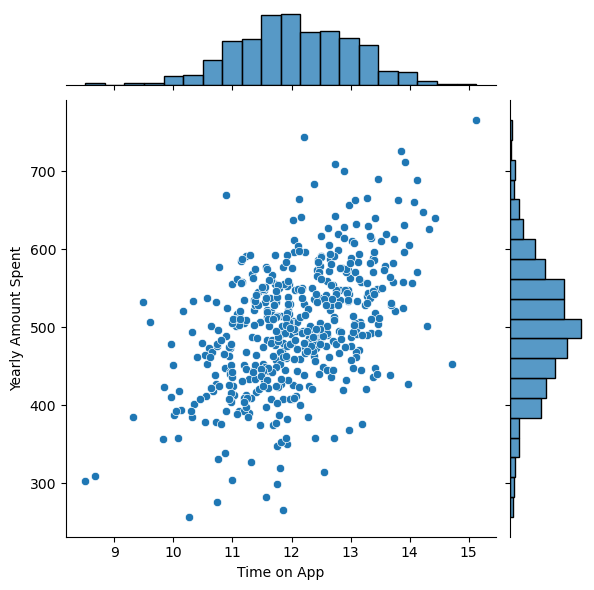

In [133]:
sns.jointplot(x='Time on App',y='Yearly Amount Spent',data=customers)

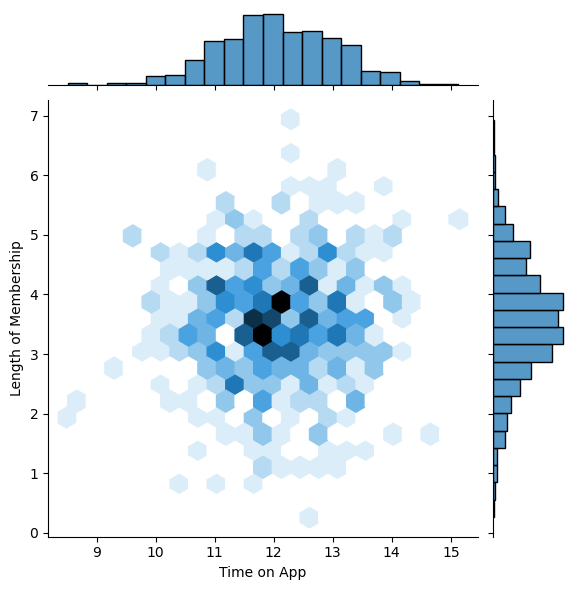

In [137]:
sns.jointplot(x='Time on App',y='Length of Membership',kind='hex',data=customers)

To choose features for a linear regression model:

1. Look for scatter plots that show linear patterns

2. Choose variables that:

Have visible linear trend

Are not completely random/scattered

3. Avoid:

    * Strongly curved relationships (nonlinear)

    * Flat, horizontal plots (no effect)

    * Strongly correlated predictors (to avoid multicollinearity)

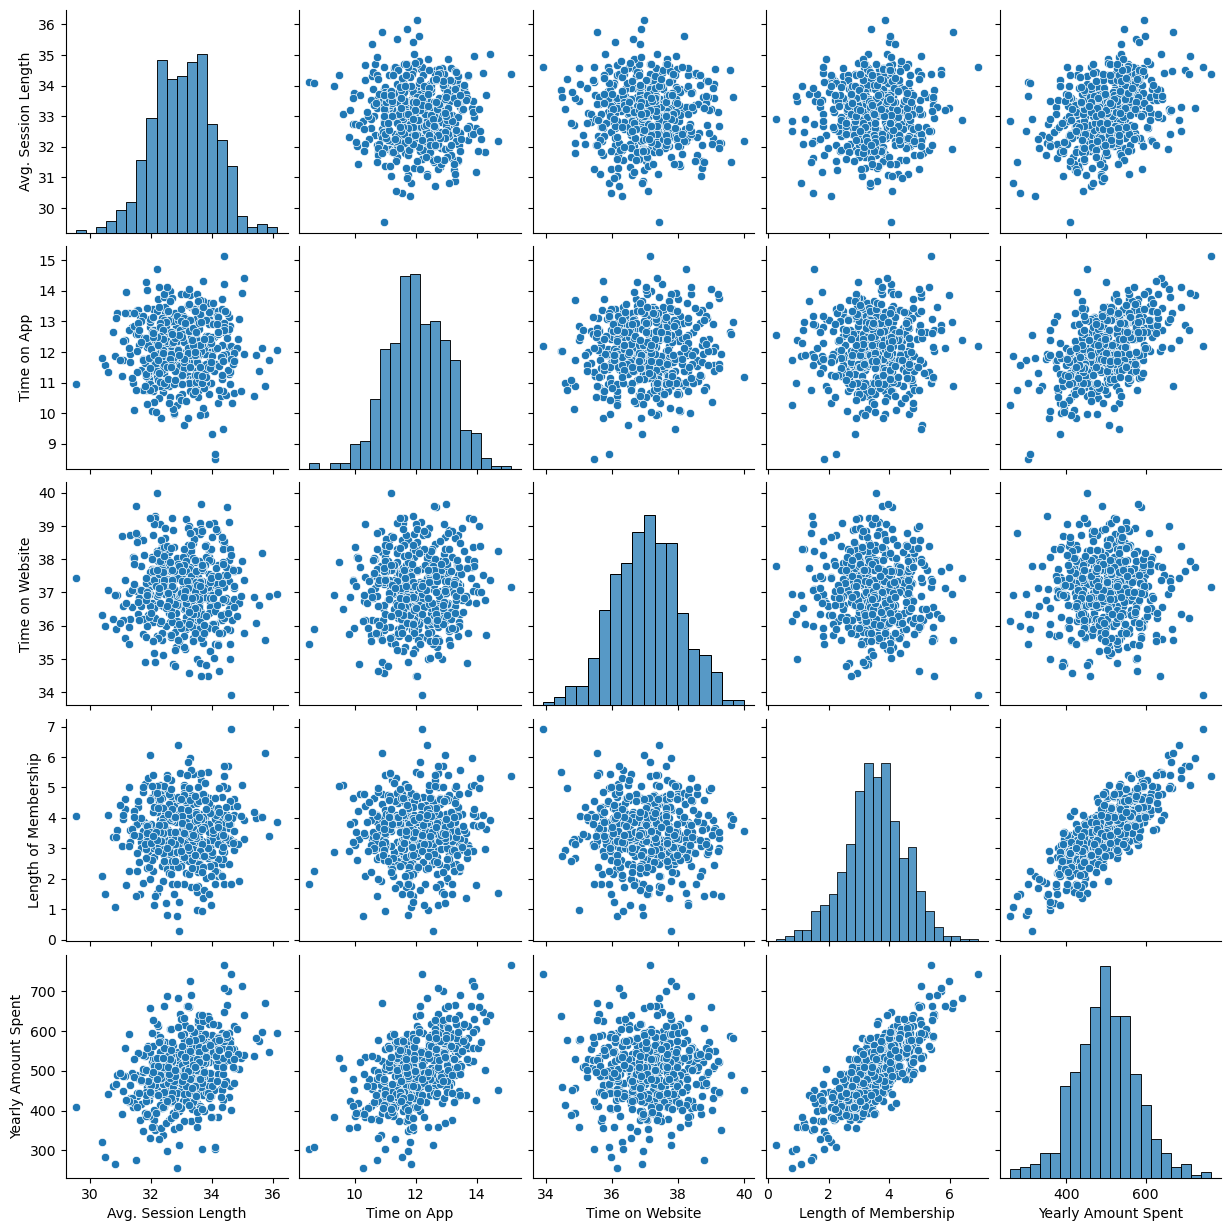

In [127]:
sns.pairplot(customers)

### We can see a good linear fit on this data, very little error as far as these error bar scales
as we already know the longer you stay as a member the higher yearly amount expenditure you are going to have

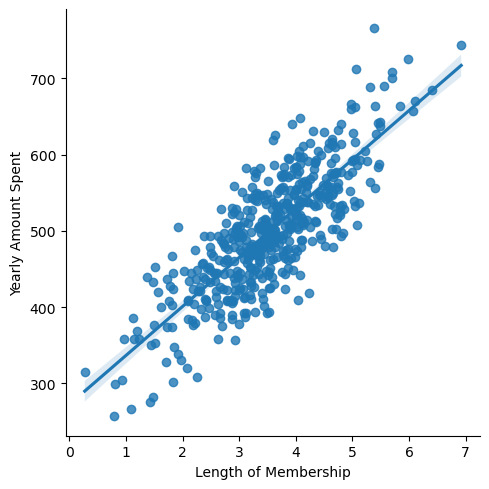

In [145]:

sns.lmplot(x='Length of Membership',y='Yearly Amount Spent',data=customers)

## Training and Testing Data
Assign the numerical features of the customers to a variable `X` and the **"Yearly Amount Spent"** column to a variable `y`.

In [143]:
customers.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

In [151]:
X=customers.select_dtypes(include='number')

In [155]:
X.head(5)

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,39.577668,4.082621,587.951054
1,31.926272,11.109461,37.268959,2.664034,392.204933
2,33.000915,11.330278,37.110597,4.104543,487.547505
3,34.305557,13.717514,36.721283,3.120179,581.852344
4,33.330673,12.795189,37.536653,4.446308,599.406092


In [157]:
# X = customers[['Avg. Session Length', 'Time on App','Time on Website', 'Length of Membership']]
X = X[['Avg. Session Length', 'Time on App','Time on Website', 'Length of Membership']]

In [159]:
# y=customers['Yearly Amount Spent']
y = customers['Yearly Amount Spent']

In [39]:
from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [46]:
y_test

,Yearly Amount Spent
18,452.315675
361,401.033135
104,410.069611
4,599.406092
156,586.155870
...,...
147,479.731938
346,488.387526
423,461.112248
17,407.704548


In [47]:
from sklearn.linear_model import LinearRegression

In [49]:
lm=LinearRegression()

In [50]:
lm.fit(X_train,y_train)

LinearRegression()

In [53]:
# The coefficients
print('Coefficients: \n', lm.coef_)

Coefficients: 
 [25.98154972 38.59015875  0.19040528 61.27909654]


In [56]:
cdf=pd.DataFrame(lm.coef_,X.columns,columns=['Coeff.'])
cdf

,Coeff.
Avg. Session Length,25.981550
Time on App,38.590159
Time on Website,0.190405
Length of Membership,61.279097


In [57]:
print("Intercept:", lm.intercept_)

Intercept: -1047.9327822502391


# Predicting Test Data

In [58]:
predictions=lm.predict(X_test)

In [59]:
predictions

array([456.44186104, 402.72005312, 409.2531539 , 591.4310343 ,
       590.01437275, 548.82396607, 577.59737969, 715.44428115,
       473.7893446 , 545.9211364 , 337.8580314 , 500.38506697,
       552.93478041, 409.6038964 , 765.52590754, 545.83973731,
       693.25969124, 507.32416226, 573.10533175, 573.2076631 ,
       397.44989709, 555.0985107 , 458.19868141, 482.66899911,
       559.2655959 , 413.00946082, 532.25727408, 377.65464817,
       535.0209653 , 447.80070905, 595.54339577, 667.14347072,
       511.96042791, 573.30433971, 505.02260887, 565.30254655,
       460.38785393, 449.74727868, 422.87193429, 456.55615271,
       598.10493696, 449.64517443, 615.34948995, 511.88078685,
       504.37568058, 515.95249276, 568.64597718, 551.61444684,
       356.5552241 , 464.9759817 , 481.66007708, 534.2220025 ,
       256.28674001, 505.30810714, 520.01844434, 315.0298707 ,
       501.98080155, 387.03842642, 472.97419543, 432.8704675 ,
       539.79082198, 590.03070739, 752.86997652, 558.27

# Evaluation

Text(0, 0.5, 'Predicted Y')

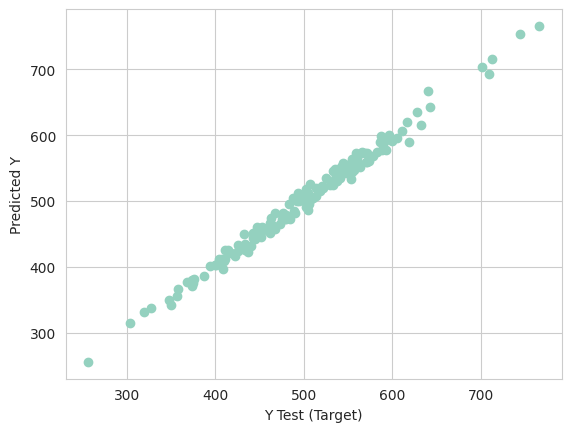

In [62]:
plt.scatter(y_test,predictions)
plt.xlabel('Y Test (Target)')
plt.ylabel('Predicted Y')

### Evaluating the Model

To assess the performance of our model, we will calculate the **Residual Sum of Squares (RSS)** and the **Explained Variance Score (R²)**.

Additionally, we will compute the **Mean Absolute Error (MAE)**, **Mean Squared Error (MSE)**, and **Root Mean Squared Error (RMSE)**. You can refer to the lecture or Wikipedia for the formulas to calculate these metrics.

### Residuals
You should have obtained a well-fitting model. Let's briefly examine the residuals to ensure everything is in order with our data.

Plot a histogram of the residuals to check if they follow a normal distribution. You can use either Seaborn's distplot or simply plt.hist() for this.

In [63]:
from sklearn import metrics

print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 7.228148653430826
MSE: 79.81305165097427
RMSE: 8.933815066978624


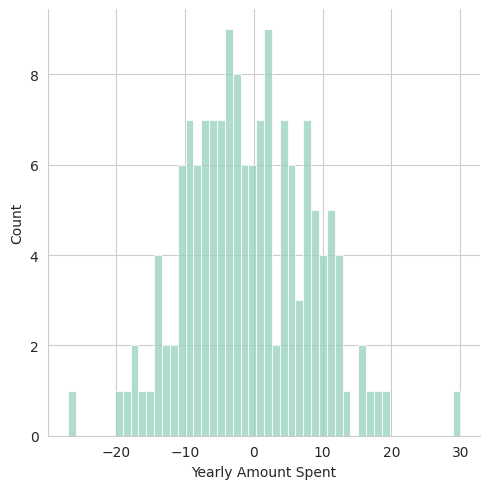

In [64]:
sns.displot((y_test-predictions),bins=50);

Third Project for Diabetes Dataset

In [161]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets, linear_model, model_selection
from sklearn.model_selection import train_test_split

The dataset's feature names are stored in data.feature_names, the columns in the DataFrame correspond to:

Features:
age: Age of the patient.
sex: Gender of the patient.
bmi: Body Mass Index.
bp: Average blood pressure.
6 other standardized medical features.
Target (y): A numeric measure of disease progression.

To deploy a linear regression model, we set `return_X_y=True` to ensure that the function returns two separate objects: one for the features and one for the target.

* **X**: The feature matrix (independent variables).
* **y**: The target vector (dependent variable).

In [166]:
data = datasets.load_diabetes()

# Convert features and target to a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # Add the target column

# View the first 5 rows
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [170]:
X, y = datasets.load_diabetes(return_X_y=True)
print(X.shape)
print(X[0])

(442, 10)
[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
 -0.04340085 -0.00259226  0.01990749 -0.01764613]


In [172]:
X = X[:,2]
print(X.shape)

(442,)


In [174]:
x_df = pd.DataFrame(X, columns=['bmi'])

# Display the DataFrame
# print(x_df)

In [176]:
x_df.head()

,bmi
0,0.061696
1,-0.051474
2,0.044451
3,-0.011595
4,-0.036385


In [178]:
X = X.reshape(-1, 1)
print(X.shape)
print(X)

(442, 1)
[[ 0.06169621]
 [-0.05147406]
 [ 0.04445121]
 [-0.01159501]
 [-0.03638469]
 [-0.04069594]
 [-0.04716281]
 [-0.00189471]
 [ 0.06169621]
 [ 0.03906215]
 [-0.08380842]
 [ 0.01750591]
 [-0.02884001]
 [-0.00189471]
 [-0.02560657]
 [-0.01806189]
 [ 0.04229559]
 [ 0.01211685]
 [-0.0105172 ]
 [-0.01806189]
 [-0.05686312]
 [-0.02237314]
 [-0.00405033]
 [ 0.06061839]
 [ 0.03582872]
 [-0.01267283]
 [-0.07734155]
 [ 0.05954058]
 [-0.02129532]
 [-0.00620595]
 [ 0.04445121]
 [-0.06548562]
 [ 0.12528712]
 [-0.05039625]
 [-0.06332999]
 [-0.03099563]
 [ 0.02289497]
 [ 0.01103904]
 [ 0.07139652]
 [ 0.01427248]
 [-0.00836158]
 [-0.06764124]
 [-0.0105172 ]
 [-0.02345095]
 [ 0.06816308]
 [-0.03530688]
 [-0.01159501]
 [-0.0730303 ]
 [-0.04177375]
 [ 0.01427248]
 [-0.00728377]
 [ 0.0164281 ]
 [-0.00943939]
 [-0.01590626]
 [ 0.0250506 ]
 [-0.04931844]
 [ 0.04121778]
 [-0.06332999]
 [-0.06440781]
 [-0.02560657]
 [-0.00405033]
 [ 0.00457217]
 [-0.00728377]
 [-0.0374625 ]
 [-0.02560657]
 [-0.02452876]
 

In [180]:
x_df = pd.DataFrame(X, columns=['Feature'])

In [182]:
x_df.head()

,Feature
0,0.061696
1,-0.051474
2,0.044451
3,-0.011595
4,-0.036385


### Train Test
This section demonstrates the complete process of training and evaluating a Linear Regression model:
**Visualization**:
   - A scatter plot is created to visualize the actual test data points.
   - The predicted regression line is plotted in blue to observe how well the model fits the data.

In [184]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

In [186]:
model = linear_model.LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [188]:
y_pred = model.predict(X_test)


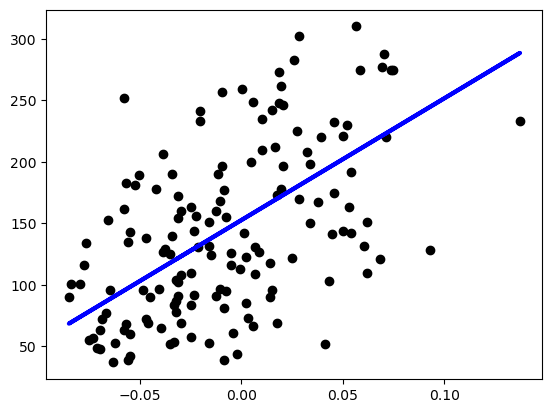

In [190]:
plt.scatter(X_test, y_test,  color='black')
plt.plot(X_test, y_pred, color='blue', linewidth=3)
plt.show()

## Third Project Pumpkin Pricing

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [254]:
pumpkin_df=pd.read_csv('US-pumpkins.csv')

**This dataset includes a lot of textual and categorical data, so let's focus on numerical price analysis.**


In [257]:
pumpkin_df.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [259]:
pumpkin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   City Name        1757 non-null   object 
 1   Type             45 non-null     object 
 2   Package          1757 non-null   object 
 3   Variety          1752 non-null   object 
 4   Sub Variety      296 non-null    object 
 5   Grade            0 non-null      float64
 6   Date             1757 non-null   object 
 7   Low Price        1757 non-null   float64
 8   High Price       1757 non-null   float64
 9   Mostly Low       1654 non-null   float64
 10  Mostly High      1654 non-null   float64
 11  Origin           1754 non-null   object 
 12  Origin District  131 non-null    object 
 13  Item Size        1478 non-null   object 
 14  Color            1141 non-null   object 
 15  Environment      0 non-null      float64
 16  Unit of Sale     162 non-null    object 
 17  Quality       

In [261]:
pumpkin_df['Package'].value_counts()

Package
36 inch bins            663
24 inch bins            551
1/2 bushel cartons      234
1 1/9 bushel cartons    117
35 lb cartons            42
bushel cartons           37
40 lb cartons            19
1 1/9 bushel crates      17
each                     17
bins                     13
50 lb sacks              11
50 lb cartons            10
bushel baskets           10
22 lb cartons            10
20 lb cartons             6
Name: count, dtype: int64

In [263]:
print("Unique values in 'Package':")
print(pumpkin_df['Package'].unique())

Unique values in 'Package':
['24 inch bins' '36 inch bins' '50 lb sacks' '1 1/9 bushel cartons'
 '1/2 bushel cartons' '1 1/9 bushel crates' 'bushel cartons' 'bins'
 '35 lb cartons' 'each' '20 lb cartons' '50 lb cartons' '40 lb cartons'
 'bushel baskets' '22 lb cartons']


* Create a DataFrame containing a subset of the data:  
  * Filter for pumpkins priced specifically by the bushel as Focusing on one unit, such as bushel, ensures uniformity in the dataset, avoiding inconsistencies caused by mixed units.
  * Convert the date field into a month format.  
  * Compute the price as the average of high and low prices.  
  * Adjust the price to reflect pricing based on bushel quantity.  

In [266]:
pumpkins_df=pumpkin_df[pumpkin_df['Package'].str.contains('bushel',case=False,regex=True)]

In [268]:
pumpkins_df.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
70,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
71,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
72,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
73,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,17.0,17.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
74,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/8/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [270]:
pumpkins_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 415 entries, 70 to 1742
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   City Name        415 non-null    object 
 1   Type             9 non-null      object 
 2   Package          415 non-null    object 
 3   Variety          415 non-null    object 
 4   Sub Variety      248 non-null    object 
 5   Grade            0 non-null      float64
 6   Date             415 non-null    object 
 7   Low Price        415 non-null    float64
 8   High Price       415 non-null    float64
 9   Mostly Low       391 non-null    float64
 10  Mostly High      391 non-null    float64
 11  Origin           415 non-null    object 
 12  Origin District  19 non-null     object 
 13  Item Size        301 non-null    object 
 14  Color            270 non-null    object 
 15  Environment      0 non-null      float64
 16  Unit of Sale     11 non-null     object 
 17  Quality          0 

In [272]:
selected_columns = ['Package', 'Variety', 'City Name', 'Low Price', 'High Price', 'Date']

In [274]:
selected_columns

['Package', 'Variety', 'City Name', 'Low Price', 'High Price', 'Date']

In [276]:
# selecting selected columns (selected_columns)
pumpkins_df = pumpkins_df.loc[:, selected_columns]

In [278]:
pumpkins_df.head()

,Package,Variety,City Name,Low Price,High Price,Date
70,1 1/9 bushel cartons,PIE TYPE,BALTIMORE,15.0,15.0,9/24/16
71,1 1/9 bushel cartons,PIE TYPE,BALTIMORE,18.0,18.0,9/24/16
72,1 1/9 bushel cartons,PIE TYPE,BALTIMORE,18.0,18.0,10/1/16
73,1 1/9 bushel cartons,PIE TYPE,BALTIMORE,17.0,17.0,10/1/16
74,1 1/9 bushel cartons,PIE TYPE,BALTIMORE,15.0,15.0,10/8/16


In [280]:
pumpkins_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 415 entries, 70 to 1742
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Package     415 non-null    object 
 1   Variety     415 non-null    object 
 2   City Name   415 non-null    object 
 3   Low Price   415 non-null    float64
 4   High Price  415 non-null    float64
 5   Date        415 non-null    object 
dtypes: float64(2), object(4)
memory usage: 22.7+ KB


In [282]:
pumpkins_df.iloc[13, 5]

'10/22/16'

In [284]:
# Helps analyze pricing trends without needing to evaluate both low and high prices separately.
# Provides a consistent metric (average price) to compare pumpkin prices across different entries or categories.
# price = pumpkins.apply(lambda row: (row['Low Price'] + row['High Price']) / 2, axis=1)
price = np.mean([pumpkins_df['Low Price'], pumpkins_df['High Price']], axis=0)

In [286]:
month=pd.DatetimeIndex(pumpkins_df['Date']).month

In [288]:
month

Index([ 9,  9, 10, 10, 10, 10, 10, 10, 10, 10,
       ...
        9,  9,  9,  9,  9,  9,  9,  9,  9,  9],
      dtype='int32', name='Date', length=415)

In [290]:
pumpkins_df['Month']=month

In [291]:
# day_of_year_2 = pd.to_datetime(pumpkins_df['Date']).apply(lambda dt: (dt-datetime(dt.year,1,1)).days)
day_of_the_year = pd.to_datetime(pumpkins_df['Date']).dt.dayofyear -1

/var/folders/z_/srqbcrjd38n00h_v2pystqp80000gn/T/ipykernel_2087/624314470.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  day_of_the_year = pd.to_datetime(pumpkins_df['Date']).dt.dayofyear -1


In [294]:
day_of_the_year

70      267
71      267
72      274
73      274
74      281
       ... 
1738    273
1739    273
1740    273
1741    273
1742    273
Name: Date, Length: 415, dtype: int32

In [296]:
pumpkins_df['DayOfYear']=day_of_the_year

In [298]:
pumpkins_df['PriceAvg']=price

In [300]:
pumpkins_df.head()

,Package,Variety,City Name,Low Price,High Price,Date,Month,DayOfYear,PriceAvg
70,1 1/9 bushel cartons,PIE TYPE,BALTIMORE,15.0,15.0,9/24/16,9,267,15.0
71,1 1/9 bushel cartons,PIE TYPE,BALTIMORE,18.0,18.0,9/24/16,9,267,18.0
72,1 1/9 bushel cartons,PIE TYPE,BALTIMORE,18.0,18.0,10/1/16,10,274,18.0
73,1 1/9 bushel cartons,PIE TYPE,BALTIMORE,17.0,17.0,10/1/16,10,274,17.0
74,1 1/9 bushel cartons,PIE TYPE,BALTIMORE,15.0,15.0,10/8/16,10,281,15.0


In [306]:
pumpkin_df = pumpkins_df[pumpkins_df['Variety'].str.contains('Jack O Lantern', na=False)]


In [308]:
pumpkin_df

,Package,Variety,City Name,Low Price,High Price,Date,Month,DayOfYear,PriceAvg


In [247]:
pumpkins_df

In [249]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

,Package,Low Price,High Price,Date,City Name


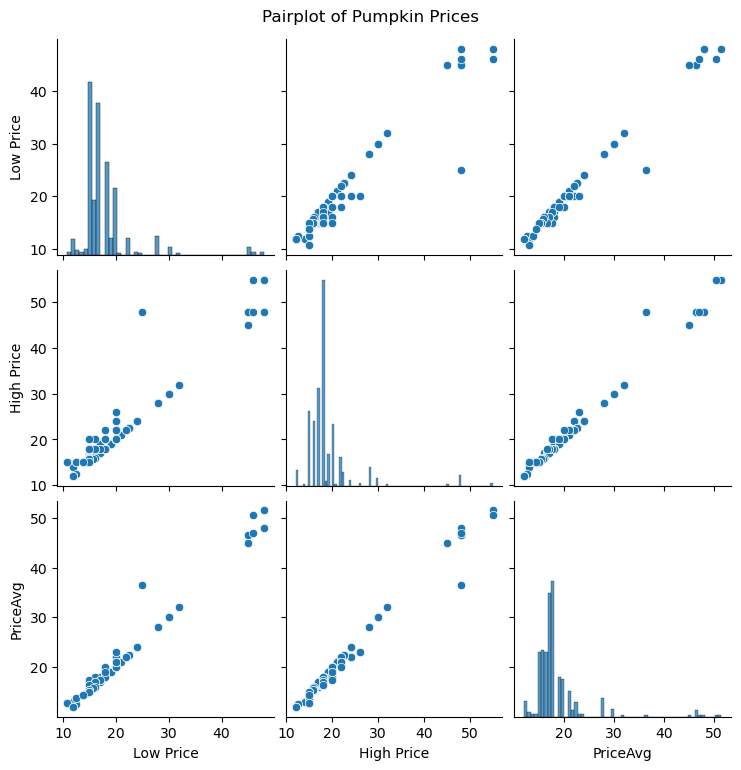

In [310]:
sns.pairplot(pumpkins_df[['Low Price', 'High Price', 'PriceAvg']])
plt.suptitle('Pairplot of Pumpkin Prices', y=1.02)
plt.show()


In [320]:
X = pumpkins_df[['Low Price', 'High Price']]
y = pumpkins_df['PriceAvg']

In [322]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [324]:
lr=LinearRegression()

In [330]:
lr.fit(X_train,y_train)

LinearRegression()

In [332]:
y_pred = lr.predict(X_test)

In [348]:
from sklearn import metrics
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 8.132718059904761e-16
MSE: 9.732452613811038e-30
RMSE: 3.1196879032702994e-15


In [352]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R-squared Score:", r2)

R-squared Score: 1.0


### Interpretation
High R² score means the model explains a lot of the variance.

Low MSE = small prediction errors.

Scatter plot close to the red line = good prediction accuracy.

If R² is close to 1, Low Price and High Price are excellent predictors of Avg Price.

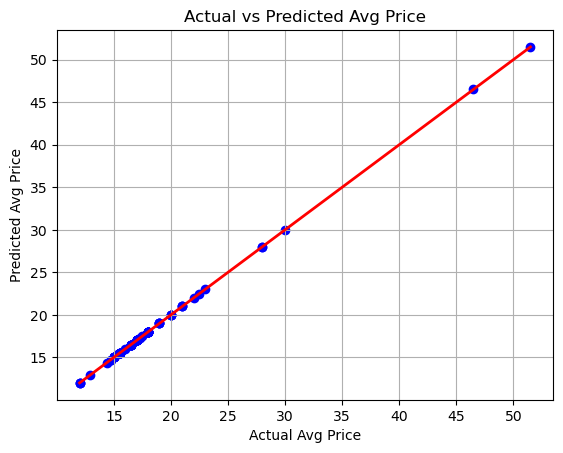

In [338]:
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linewidth=2)
plt.xlabel('Actual Avg Price')
plt.ylabel('Predicted Avg Price')
plt.title('Actual vs Predicted Avg Price')
plt.grid(True)
plt.show()


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
from sklearn.linear_model import LinearRegression

In [5]:
california=fetch_california_housing()

In [6]:
california.DESCR

'.. _california_housing_dataset:\n\nCalifornia Housing dataset\n--------------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 20640\n\n:Number of Attributes: 8 numeric, predictive attributes and the target\n\n:Attribute Information:\n    - MedInc        median income in block group\n    - HouseAge      median house age in block group\n    - AveRooms      average number of rooms per household\n    - AveBedrms     average number of bedrooms per household\n    - Population    block group population\n    - AveOccup      average number of household members\n    - Latitude      block group latitude\n    - Longitude     block group longitude\n\n:Missing Attribute Values: None\n\nThis dataset was obtained from the StatLib repository.\nhttps://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html\n\nThe target variable is the median house value for California districts,\nexpressed in hundreds of thousands of dollars ($100,000).\n\nThis dataset was derived from the 1990 U.S

In [13]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [15]:
california.data

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [17]:
columns_cal=california.feature_names

In [19]:
columns_cal

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [21]:
california.target_names

['MedHouseVal']

In [30]:
housing = fetch_california_housing(as_frame=True)
df = housing.data

In [32]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [34]:
df_numeric=df.select_dtypes(include='number')

<Axes: >

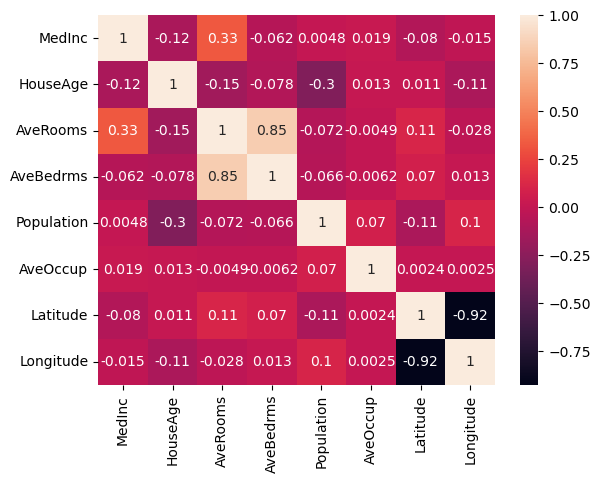

In [36]:
sns.heatmap(df_numeric.corr(),annot=True)

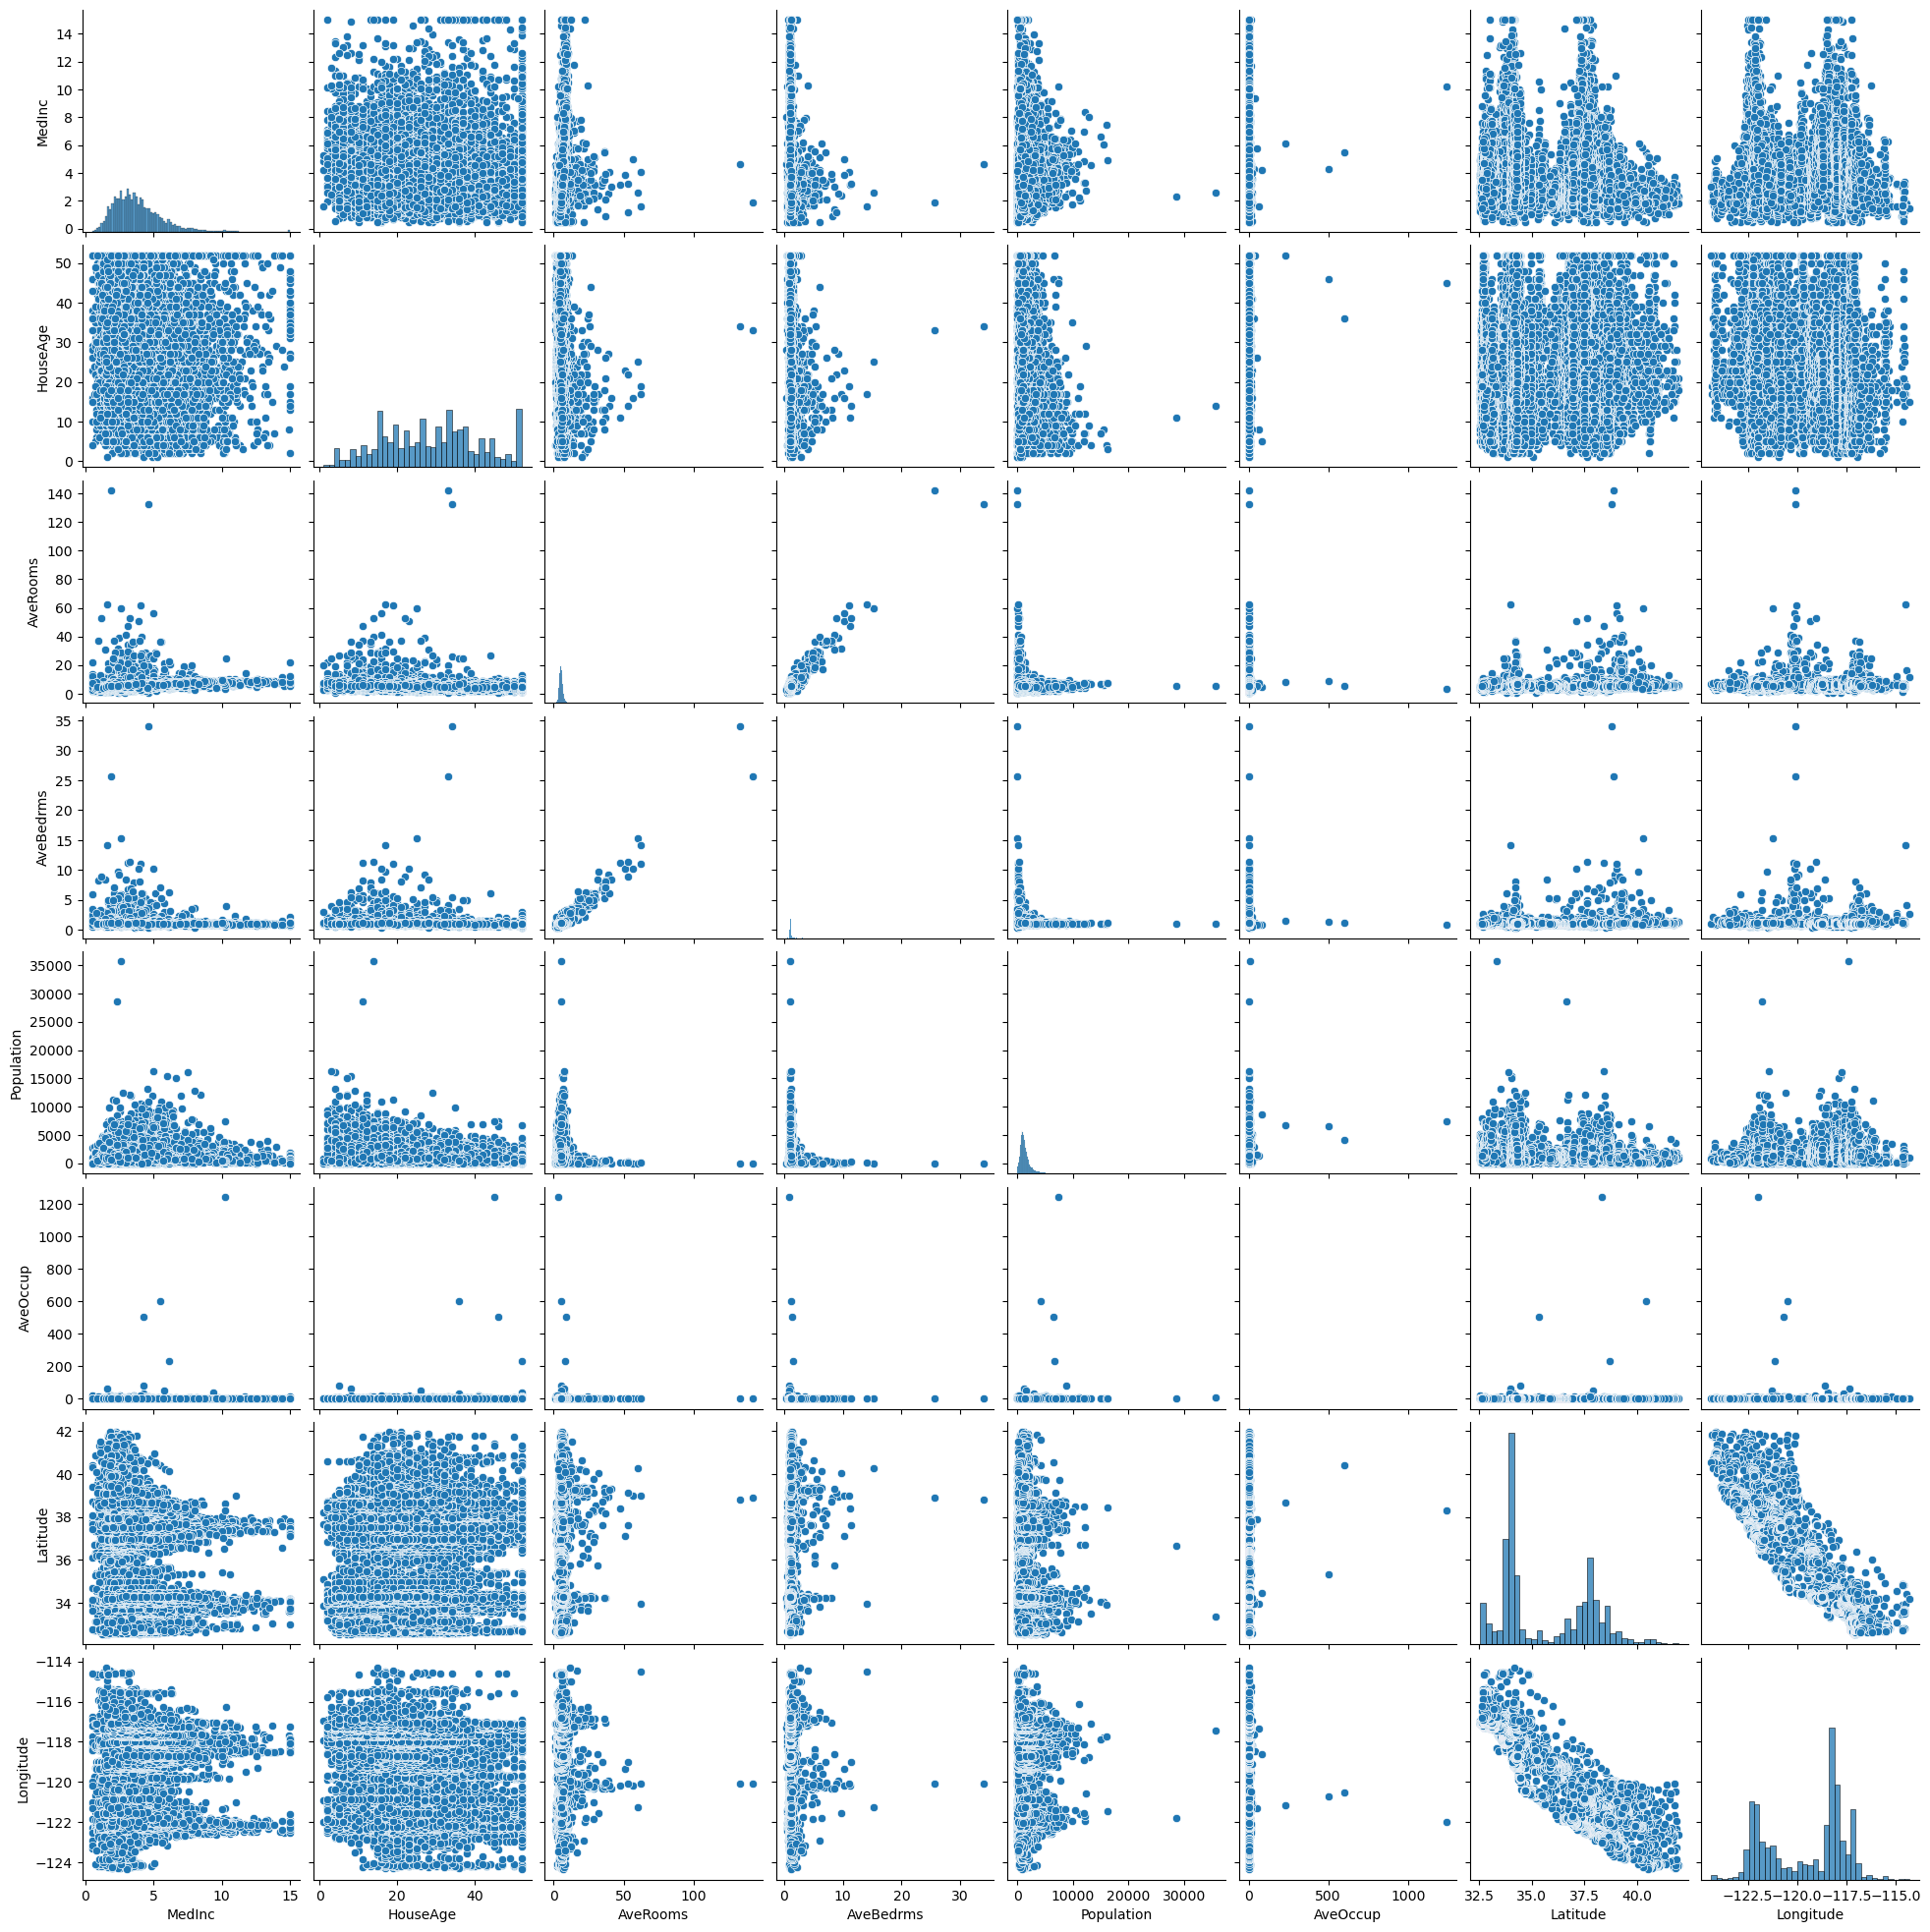

In [38]:
sns.pairplot(df)

In [39]:
df_numeric.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

In [40]:
# X=df_numeric[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
#        'Latitude', 'Longitude']]
X = df_numeric

In [51]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [61]:
# y=df_numeric[['MedHouseVal']]
y=pd.DataFrame(housing.target)

In [63]:
y

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

In [67]:
model=LinearRegression()

In [69]:
model.fit(X_train,y_train)

LinearRegression()

In [71]:
model.coef_

array([[ 4.30863349e-01,  1.02352181e-02, -1.04016683e-01,
         5.37428718e-01,  1.80375787e-05, -1.47742974e-01,
        -4.19256479e-01, -4.24321036e-01]])

In [81]:
df_coef=pd.DataFrame(model.coef_.T,X_train.columns,columns=['Coef'])

In [83]:
df_coef

,Coef
MedInc,0.430863
HouseAge,0.010235
AveRooms,-0.104017
AveBedrms,0.537429
Population,0.000018
AveOccup,-0.147743
Latitude,-0.419256
Longitude,-0.424321


In [89]:
predict=model.predict(X_test)

In [95]:
print(X_test.shape, y_test.shape)


(8256, 8) (8256, 1)


Text(0, 0.5, 'Predicted Y')

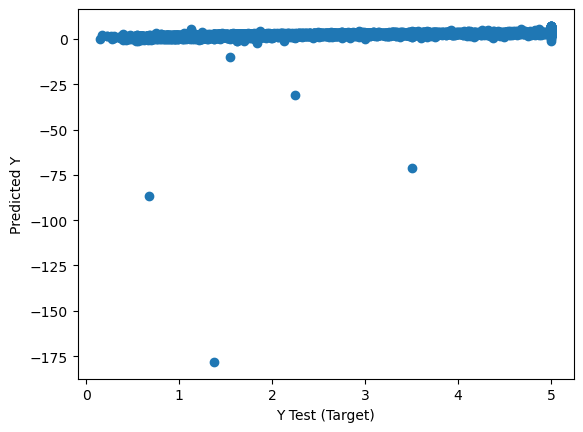

In [103]:
plt.scatter(y_test,predict)
plt.xlabel('Y Test (Target)')
plt.ylabel('Predicted Y')